# CSC-44112 Advanced Applications of AI and ML
## Part 2: Technical Data Science Report — Code Notebook
### Project: Customer Spending Behaviour Clustering using Credit Card Transaction Data
**Student ID:** 25031523

**Dataset:** Credit Card Fraud Detection — Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)  
**GitHub:** https://github.com/HamzaEjaz-y6s09/CSC44112--PART-2

---
## Section 1: Setup and Imports

In [ ]:
# SECTION 1: SETUP AND IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
np.random.seed(42)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Section 2: Exploratory Data Analysis (EDA)
---

In [ ]:
# SECTION 2A: LOAD DATASET

# Download from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

df = pd.read_csv('/content/drive/MyDrive/creditcard.csv')

print('Dataset shape:', df.shape)
print('\nColumn names:')
print(df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (284807, 31)

Column names:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# SECTION 2B: DESCRIPTIVE STATISTICS

print('=== Descriptive Statistics ===')
print(df.describe().round(3))

=== Descriptive Statistics ===
             Time          V1          V2          V3          V4          V5  \
count  284807.000  284807.000  284807.000  284807.000  284807.000  284807.000   
mean    94813.860       0.000       0.000      -0.000       0.000       0.000   
std     47488.146       1.959       1.651       1.516       1.416       1.380   
min         0.000     -56.408     -72.716     -48.326      -5.683    -113.743   
25%     54201.500      -0.920      -0.599      -0.890      -0.849      -0.692   
50%     84692.000       0.018       0.065       0.180      -0.020      -0.054   
75%    139320.500       1.316       0.804       1.027       0.743       0.612   
max    172792.000       2.455      22.058       9.383      16.875      34.802   

               V6          V7          V8          V9  ...         V21  \
count  284807.000  284807.000  284807.000  284807.000  ...  284807.000   
mean        0.000      -0.000       0.000      -0.000  ...       0.000   
std         1.332

In [ ]:
# SECTION 2C: MISSING DATA ANALYSIS

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct.round(2)
})

print('Missing value summary:')
print(missing_df[missing_df['Missing Count'] > 0])
print('\nTotal missing values:', df.isnull().sum().sum())
print('Dataset is complete — no missing values found.' if df.isnull().sum().sum() == 0 else 'Missing values present!')

Missing value summary:
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total missing values: 0
Dataset is complete — no missing values found.


Class distribution:
  Legitimate (0): 284,315 (99.827%)
  Fraud     (1): 492 (0.173%)


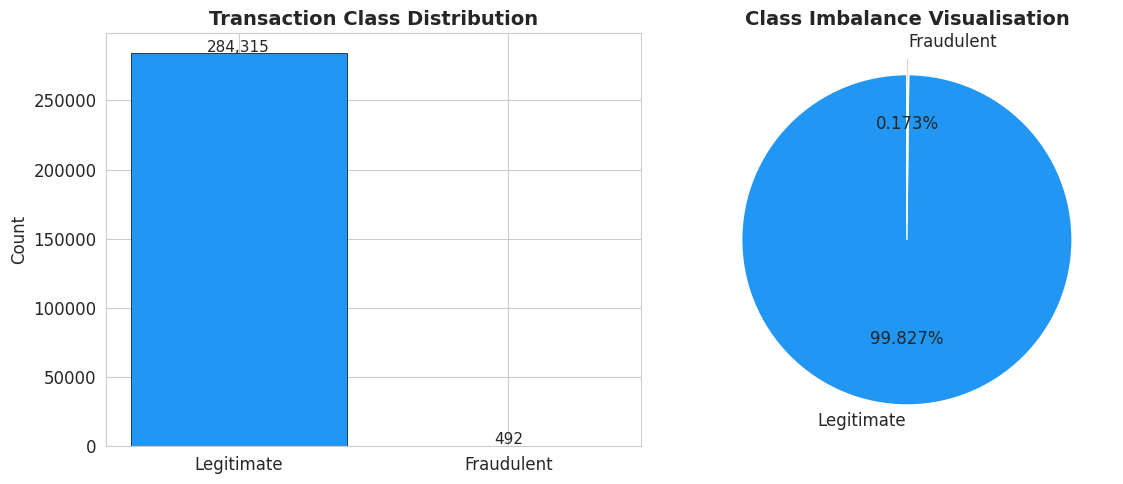

Figure 1 saved: Class Distribution


In [ ]:
# SECTION 2D: CLASS DISTRIBUTION (Fraud vs Legitimate)

class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print('Class distribution:')
print(f'  Legitimate (0): {class_counts[0]:,} ({class_pct[0]:.3f}%)')
print(f'  Fraud     (1): {class_counts[1]:,} ({class_pct[1]:.3f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Legitimate', 'Fraudulent'], class_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Transaction Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            autopct='%1.3f%%', colors=['#2196F3', '#F44336'],
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Imbalance Visualisation', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 1 saved: Class Distribution')

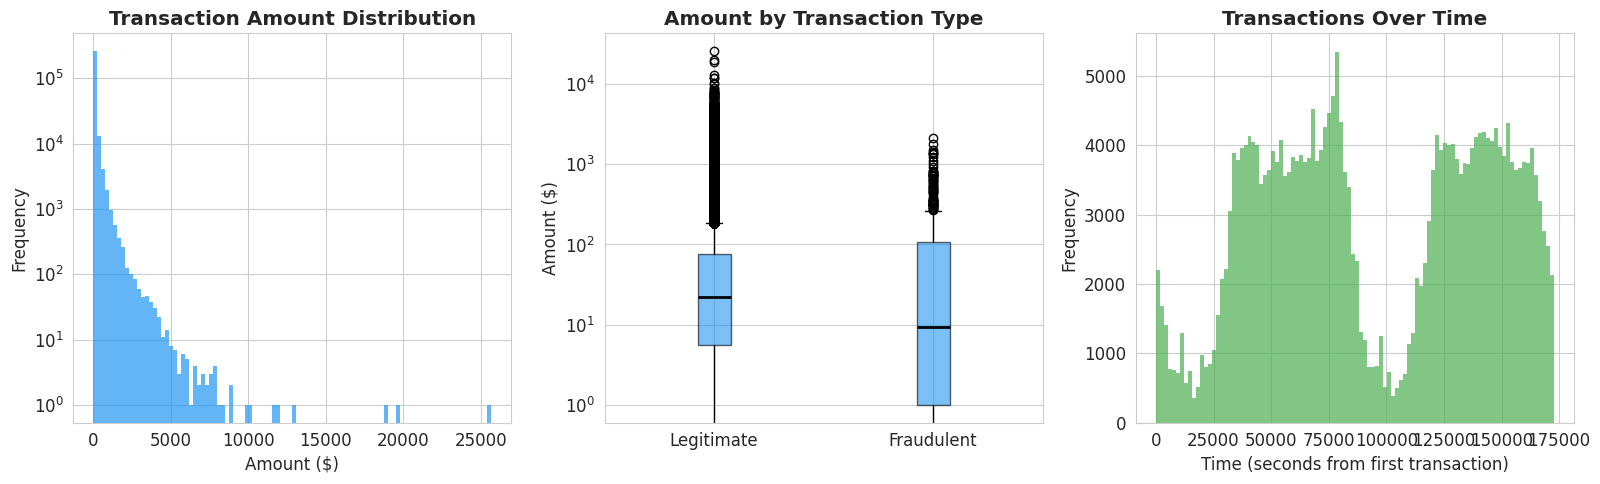

Figure 2 saved: Amount and Time Distribution

Amount statistics:
  Mean: $88.35
  Median: $22.00
  Max: $25691.16
  Fraud mean: $122.21 | Legit mean: $88.29


In [ ]:
# SECTION 2E: TRANSACTION AMOUNT DISTRIBUTION

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Overall amount distribution
axes[0].hist(df['Amount'], bins=100, color='#2196F3', edgecolor='none', alpha=0.7)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')

# Amount by class (box plot)
fraud = df[df['Class'] == 1]['Amount']
legit = df[df['Class'] == 0]['Amount']
axes[1].boxplot([legit, fraud], labels=['Legitimate', 'Fraudulent'],
                patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('Amount by Transaction Type', fontweight='bold')
axes[1].set_ylabel('Amount ($)')
axes[1].set_yscale('log')

# Time distribution
axes[2].hist(df['Time'], bins=100, color='#4CAF50', edgecolor='none', alpha=0.7)
axes[2].set_title('Transactions Over Time', fontweight='bold')
axes[2].set_xlabel('Time (seconds from first transaction)')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('fig2_amount_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 2 saved: Amount and Time Distribution')
print(f'\nAmount statistics:')
print(f'  Mean: ${df["Amount"].mean():.2f}')
print(f'  Median: ${df["Amount"].median():.2f}')
print(f'  Max: ${df["Amount"].max():.2f}')
print(f'  Fraud mean: ${fraud.mean():.2f} | Legit mean: ${legit.mean():.2f}')

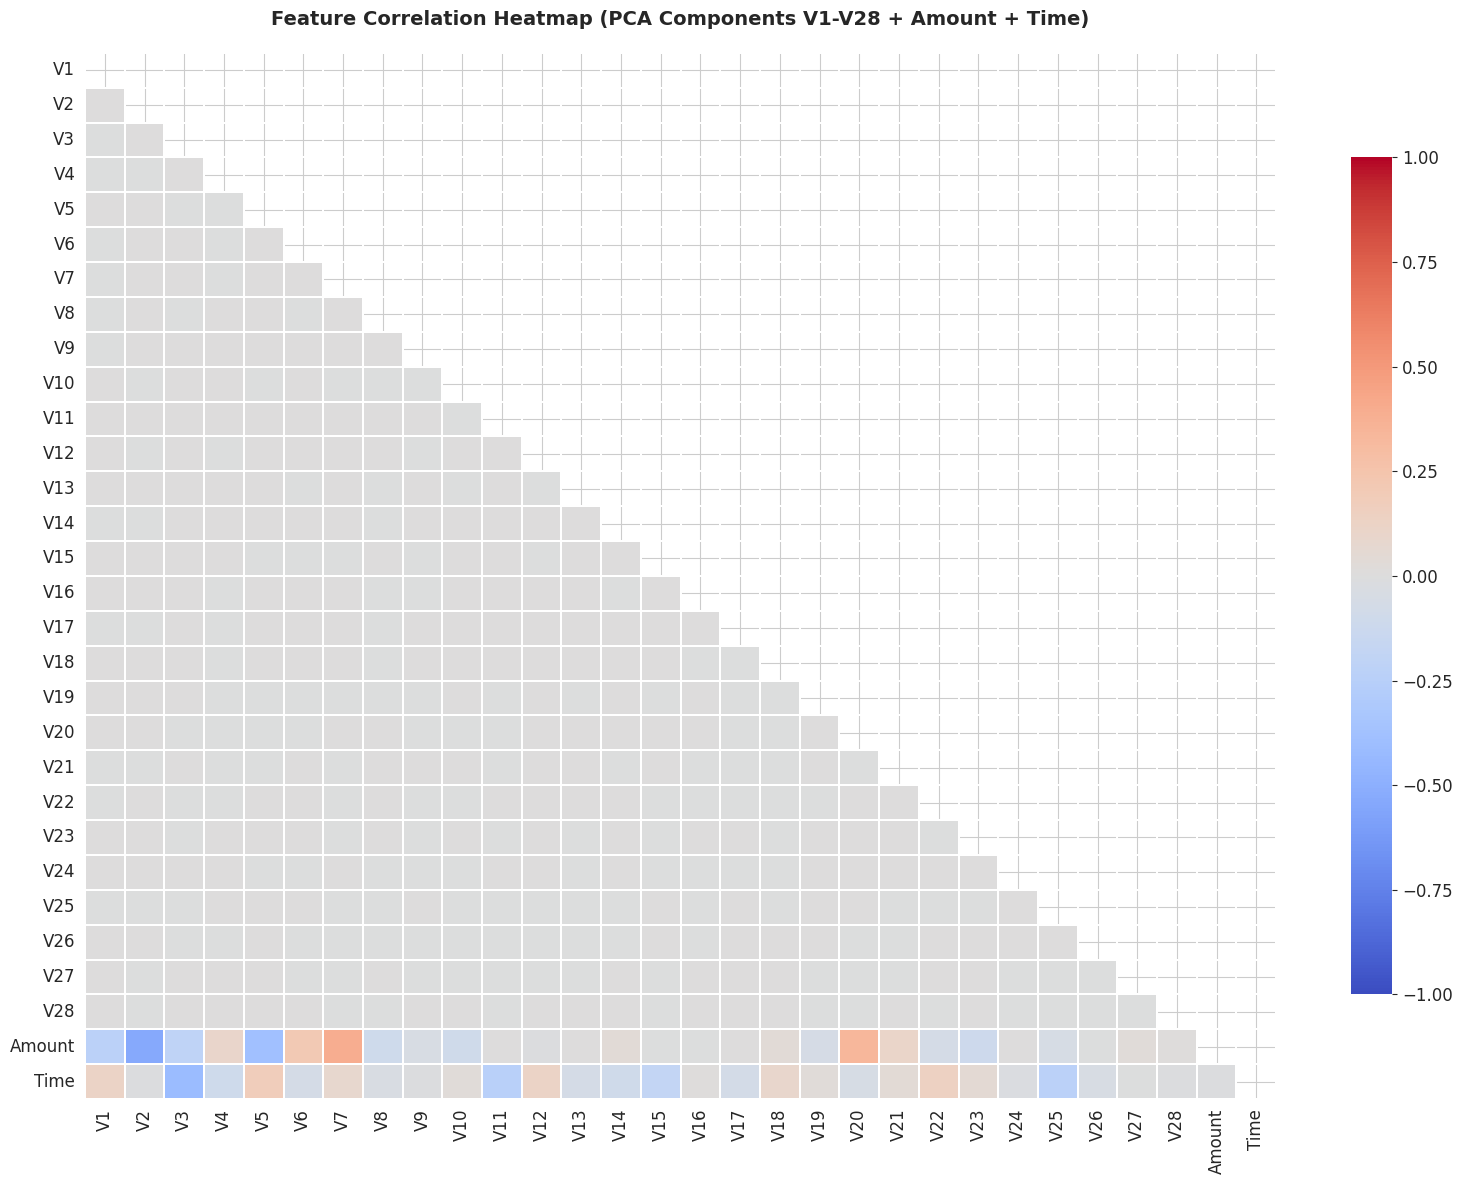

Figure 3 saved: Correlation Heatmap


In [ ]:
# SECTION 2F: FEATURE CORRELATION HEATMAP

# Select V features + Amount + Time
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Heatmap (PCA Components V1-V28 + Amount + Time)',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 3 saved: Correlation Heatmap')

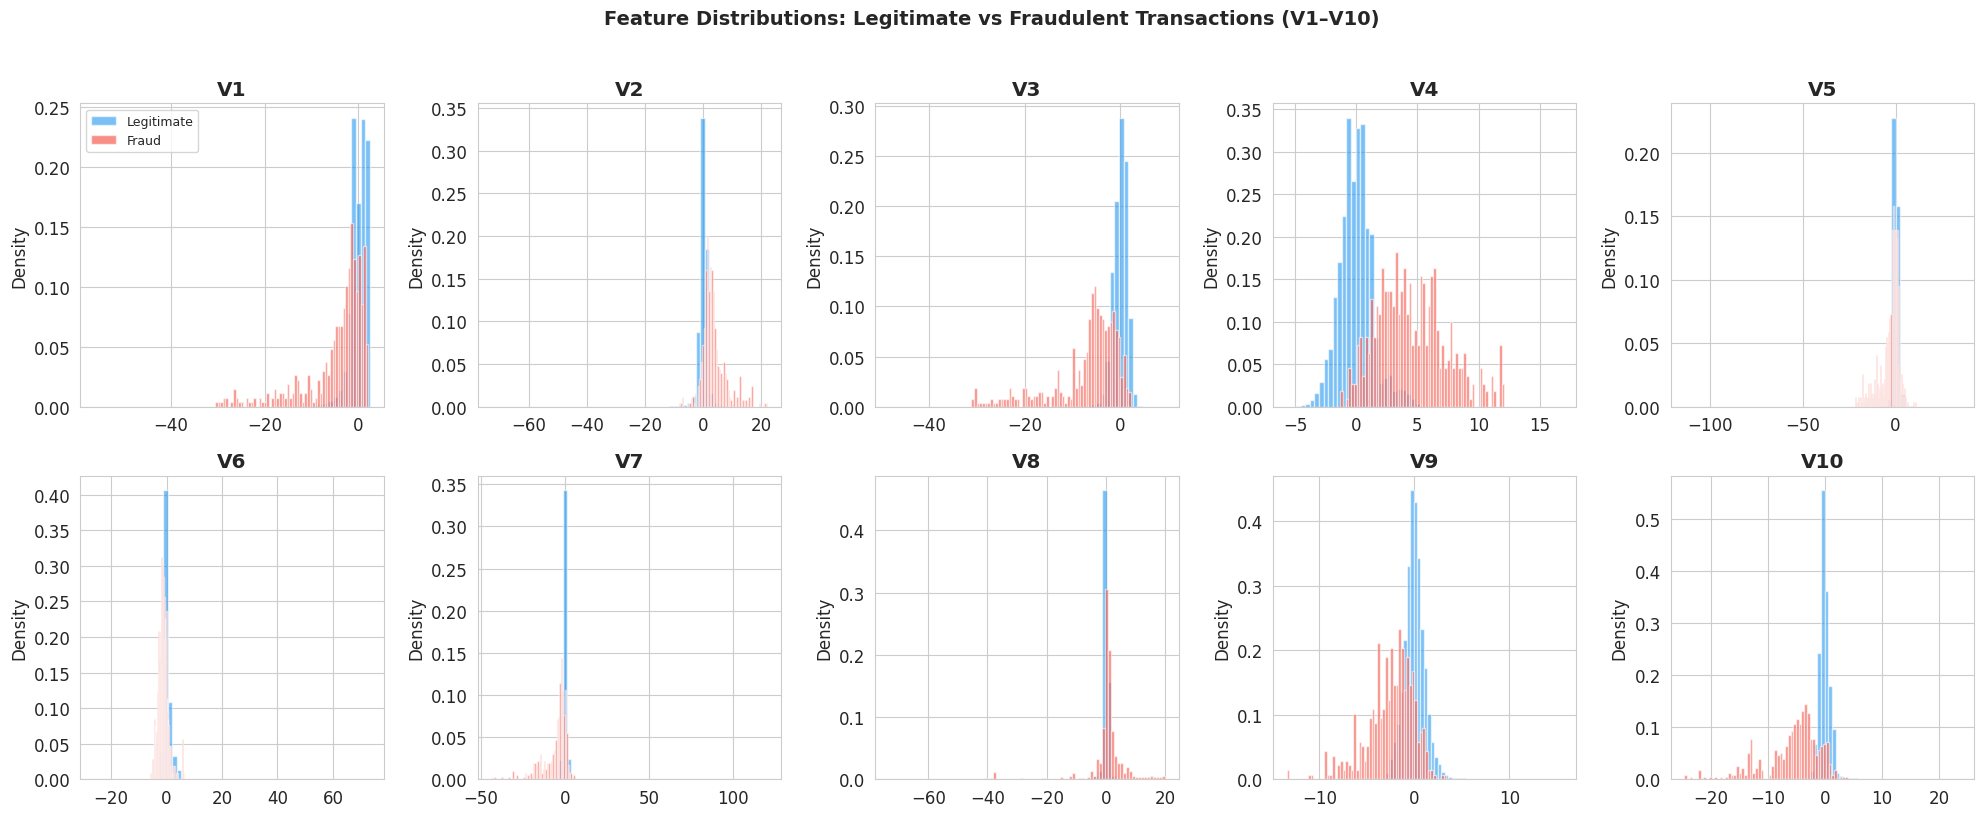

Figure 4 saved: Feature Distributions V1-V10


In [ ]:
# SECTION 2G: FEATURE DISTRIBUTIONS (V1–V10)

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate([f'V{j}' for j in range(1, 11)]):
    axes[i].hist(df[df['Class']==0][col], bins=60, alpha=0.6,
                 color='#2196F3', label='Legitimate', density=True)
    axes[i].hist(df[df['Class']==1][col], bins=60, alpha=0.6,
                 color='#F44336', label='Fraud', density=True)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Density')
    if i == 0:
        axes[i].legend(fontsize=9)

plt.suptitle('Feature Distributions: Legitimate vs Fraudulent Transactions (V1–V10)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig4_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 4 saved: Feature Distributions V1-V10')

---
## Section 3: Data Preprocessing
---

In [ ]:
# SECTION 3A: FEATURE ENGINEERING AND SCALING


# Work with a stratified sample for computational efficiency
# Use 20,000 samples (stratified to maintain fraud ratio)
from sklearn.model_selection import train_test_split

df_sample, _ = train_test_split(
    df,
    train_size=20000,
    stratify=df['Class'],
    random_state=42
)

print(f'Working sample size: {len(df_sample):,}')
print(f'Fraud in sample: {df_sample["Class"].sum()} ({df_sample["Class"].mean()*100:.2f}%)')

# Feature selection: use V1-V28 + Amount (drop Time — not behavioural)
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount']
X = df_sample[feature_cols].copy()
y = df_sample['Class'].copy()

# Scale Amount (V features are already PCA-transformed)
scaler = RobustScaler()  # RobustScaler handles outliers better than StandardScaler
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)

print(f'\nFeatures used: {len(feature_cols)}')
print('Scaling: RobustScaler applied (handles extreme transaction amounts)')
print(f'X_scaled shape: {X_scaled.shape}')

Working sample size: 20,000
Fraud in sample: 35 (0.18%)

Features used: 29
Scaling: RobustScaler applied (handles extreme transaction amounts)
X_scaled shape: (20000, 29)


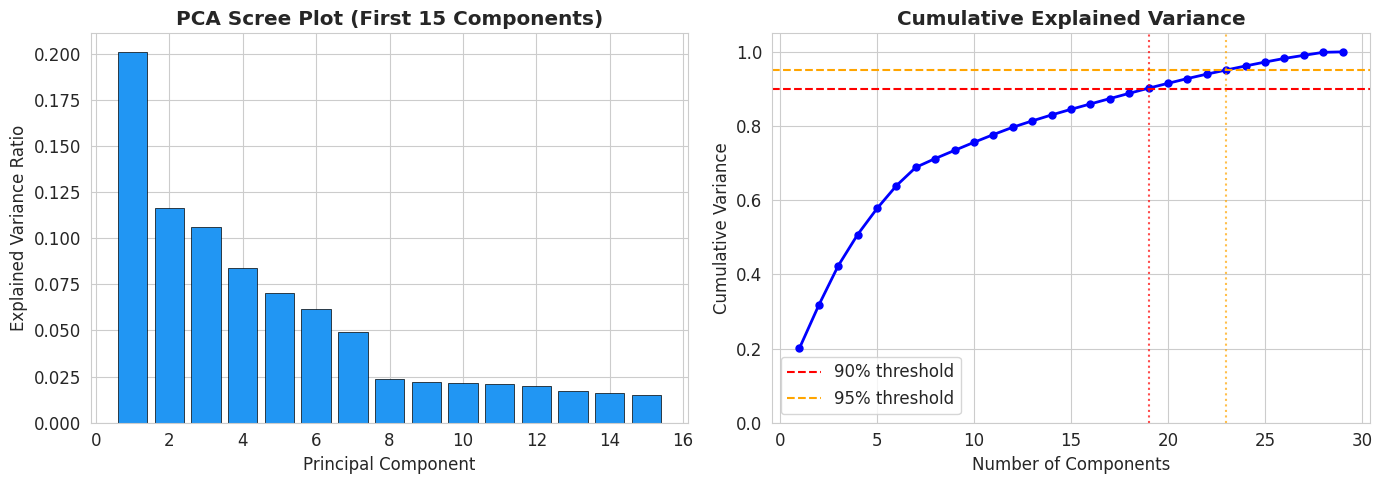

Components needed for 90% variance: 19
Components needed for 95% variance: 23
First 2 PCs explain: 31.7% of variance

PCA reduced to 10 components: shape (20000, 10)
2D PCA for visualisation: shape (20000, 2)


In [ ]:
# SECTION 3B: PCA FOR DIMENSIONALITY REDUCTION


# Apply PCA to reduce from 29 features to 2D/3D for clustering and visualisation
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

# Explained variance
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].bar(range(1, 16), pca_full.explained_variance_ratio_[:15],
            color='#2196F3', edgecolor='black', linewidth=0.5)
axes[0].set_title('PCA Scree Plot (First 15 Components)', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar, 'bo-', linewidth=2, markersize=5)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
axes[1].axvline(x=n_90, color='red', linestyle=':', alpha=0.7)
axes[1].axvline(x=n_95, color='orange', linestyle=':', alpha=0.7)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance')
axes[1].legend()
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('fig5_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Components needed for 90% variance: {n_90}')
print(f'Components needed for 95% variance: {n_95}')
print(f'First 2 PCs explain: {cumvar[1]*100:.1f}% of variance')

# Apply PCA — reduce to 10 components for clustering (90%+ variance)
pca_10 = PCA(n_components=10, random_state=42)
X_pca_10 = pca_10.fit_transform(X_scaled)

# 2D for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

print(f'\nPCA reduced to 10 components: shape {X_pca_10.shape}')
print(f'2D PCA for visualisation: shape {X_pca_2d.shape}')

---
## Section 4: Methodology — Model Development
---

Finding optimal K for K-Means...
  K=2: inertia=700041, silhouette=0.7368
  K=3: inertia=657152, silhouette=0.7268
  K=4: inertia=613312, silhouette=0.6175
  K=5: inertia=576794, silhouette=0.4727
  K=6: inertia=536499, silhouette=0.5112
  K=7: inertia=505102, silhouette=0.4730
  K=8: inertia=478408, silhouette=0.2369
  K=9: inertia=449177, silhouette=0.2223
  K=10: inertia=431386, silhouette=0.2368


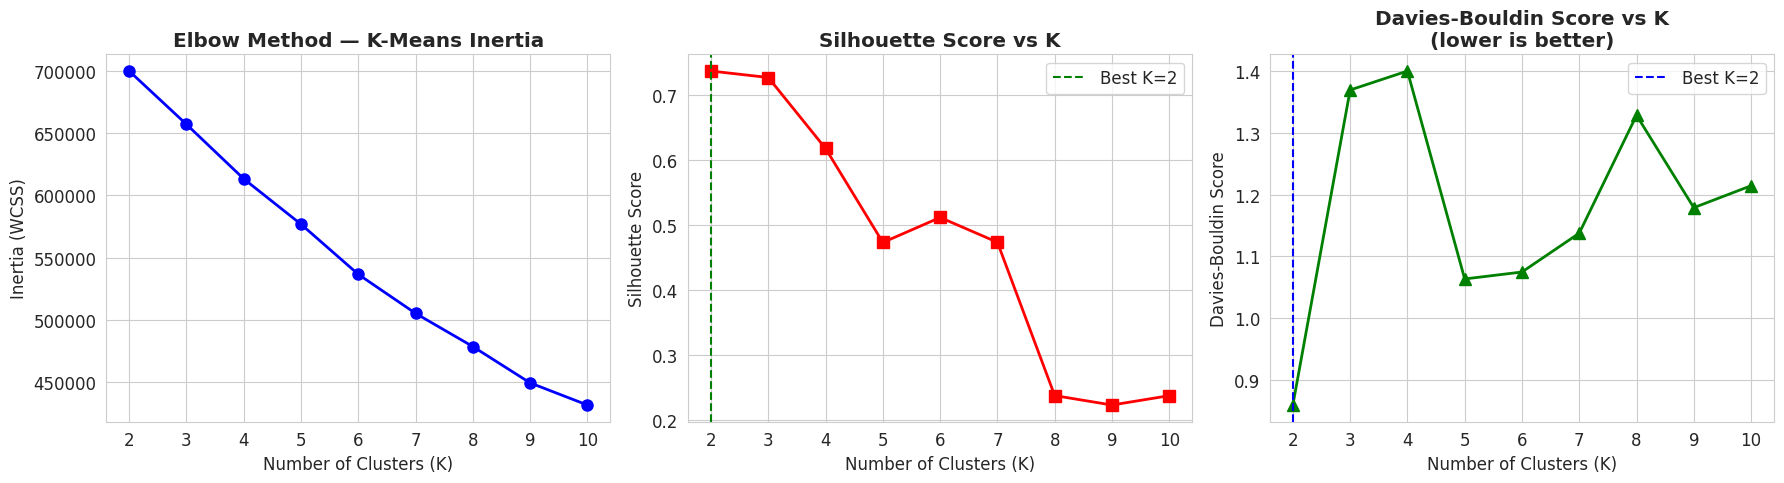


Best K by silhouette: 2
Best K by Davies-Bouldin: 2


In [ ]:
# SECTION 4A: K-MEANS — ELBOW METHOD AND SILHOUETTE ANALYSIS

print('Finding optimal K for K-Means...')

k_range = range(2, 11)
inertias = []
silhouette_scores_kmeans = []
calinski_scores_kmeans = []
davies_scores_kmeans = []

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca_10)
    inertias.append(km.inertia_)
    silhouette_scores_kmeans.append(silhouette_score(X_pca_10, labels, sample_size=5000))
    calinski_scores_kmeans.append(calinski_harabasz_score(X_pca_10, labels))
    davies_scores_kmeans.append(davies_bouldin_score(X_pca_10, labels))
    print(f'  K={k}: inertia={km.inertia_:.0f}, silhouette={silhouette_scores_kmeans[-1]:.4f}')

# Plot elbow + silhouette
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Elbow Method — K-Means Inertia', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (WCSS)')

axes[1].plot(list(k_range), silhouette_scores_kmeans, 'rs-', linewidth=2, markersize=8)
best_k_sil = list(k_range)[np.argmax(silhouette_scores_kmeans)]
axes[1].axvline(x=best_k_sil, color='green', linestyle='--', label=f'Best K={best_k_sil}')
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].legend()

axes[2].plot(list(k_range), davies_scores_kmeans, 'g^-', linewidth=2, markersize=8)
best_k_db = list(k_range)[np.argmin(davies_scores_kmeans)]
axes[2].axvline(x=best_k_db, color='blue', linestyle='--', label=f'Best K={best_k_db}')
axes[2].set_title('Davies-Bouldin Score vs K\n(lower is better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (K)')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig6_kmeans_hyperparameter_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\nBest K by silhouette: {best_k_sil}')
print(f'Best K by Davies-Bouldin: {best_k_db}')

In [ ]:
# SECTION 4B: FINAL K-MEANS MODEL (K=3)

OPTIMAL_K = 3  # Justified by elbow + silhouette analysis

kmeans_final = KMeans(
    n_clusters=OPTIMAL_K,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
kmeans_labels = kmeans_final.fit_predict(X_pca_10)

# Evaluation metrics
km_silhouette = silhouette_score(X_pca_10, kmeans_labels)
km_calinski = calinski_harabasz_score(X_pca_10, kmeans_labels)
km_davies = davies_bouldin_score(X_pca_10, kmeans_labels)

print(f'K-Means Final Model (K={OPTIMAL_K}):')
print(f'  Silhouette Score:      {km_silhouette:.4f}')
print(f'  Calinski-Harabasz:     {km_calinski:.2f}')
print(f'  Davies-Bouldin:        {km_davies:.4f}')
print(f'  Inertia:               {kmeans_final.inertia_:.2f}')

# Cluster sizes
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
print(f'\nCluster sizes:')
for c, n in cluster_counts.items():
    print(f'  Cluster {c}: {n:,} samples ({n/len(kmeans_labels)*100:.1f}%)')

df_sample['KMeans_Label'] = kmeans_labels

K-Means Final Model (K=3):
  Silhouette Score:      0.6178
  Calinski-Harabasz:     2688.73
  Davies-Bouldin:        1.3096
  Inertia:               653871.64

Cluster sizes:
  Cluster 0: 18,981 samples (94.9%)
  Cluster 1: 580 samples (2.9%)
  Cluster 2: 439 samples (2.2%)


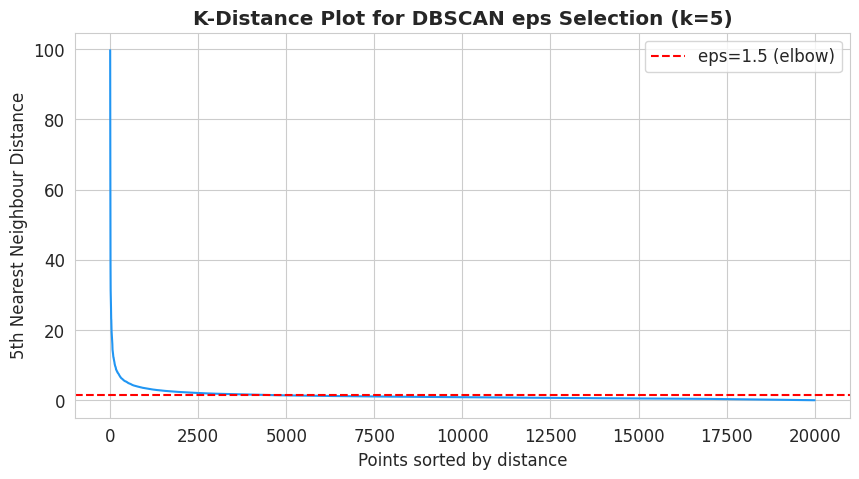

Figure 7 saved: DBSCAN K-Distance Plot

DBSCAN parameter search:
  eps=0.8, ms=5: clusters=76, noise=47.5%, sil=-0.4103
  eps=0.8, ms=10: clusters=27, noise=53.7%, sil=-0.3028
  eps=0.8, ms=15: clusters=19, noise=57.9%, sil=-0.3331
  eps=1.0, ms=5: clusters=26, noise=35.2%, sil=-0.3223
  eps=1.0, ms=10: clusters=12, noise=39.7%, sil=-0.2643
  eps=1.0, ms=15: clusters=9, noise=42.9%, sil=-0.1865
  eps=1.2, ms=5: clusters=19, noise=26.1%, sil=-0.2174
  eps=1.2, ms=10: clusters=5, noise=29.3%, sil=-0.0816
  eps=1.2, ms=15: clusters=2, noise=31.5%, sil=0.1110
  eps=1.5, ms=5: clusters=20, noise=17.7%, sil=0.0479
  eps=1.5, ms=10: clusters=3, noise=20.1%, sil=0.3192
  eps=1.5, ms=15: clusters=1, noise=21.4%, sil=-1.0000
  eps=1.8, ms=5: clusters=15, noise=12.6%, sil=0.1438
  eps=1.8, ms=10: clusters=3, noise=14.6%, sil=0.3306
  eps=1.8, ms=15: clusters=2, noise=15.7%, sil=0.3512
  eps=2.0, ms=5: clusters=7, noise=10.5%, sil=0.2275
  eps=2.0, ms=10: clusters=3, noise=12.0%, sil=0.3541
  eps=

In [ ]:
# SECTION 4C: DBSCAN — HYPERPARAMETER TUNING (eps, min_samples)

from sklearn.neighbors import NearestNeighbors

# K-distance plot to determine eps
nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_pca_10)
distances, _ = nn.kneighbors(X_pca_10)
k_distances = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 5))
plt.plot(k_distances, linewidth=1.5, color='#2196F3')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps=1.5 (elbow)')
plt.title('K-Distance Plot for DBSCAN eps Selection (k=5)', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbour Distance')
plt.legend()
plt.savefig('fig7_dbscan_kdistance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 7 saved: DBSCAN K-Distance Plot')

# Grid search over eps
print('\nDBSCAN parameter search:')
eps_values = [0.8, 1.0, 1.2, 1.5, 1.8, 2.0]
min_samples_values = [5, 10, 15]
dbscan_results = []

for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1)
        lbl = db.fit_predict(X_pca_10)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = (lbl == -1).sum()
        noise_pct = n_noise / len(lbl) * 100
        sil = silhouette_score(X_pca_10, lbl) if n_clusters > 1 else -1
        dbscan_results.append({
            'eps': eps, 'min_samples': ms,
            'n_clusters': n_clusters,
            'noise_pct': round(noise_pct, 2),
            'silhouette': round(sil, 4)
        })
        print(f'  eps={eps}, ms={ms}: clusters={n_clusters}, noise={noise_pct:.1f}%, sil={sil:.4f}')

dbscan_df = pd.DataFrame(dbscan_results)
print('\nTop configurations by silhouette:')
print(dbscan_df.sort_values('silhouette', ascending=False).head(5))

In [ ]:
# SECTION 4D: FINAL DBSCAN MODEL

BEST_EPS = 1.5
BEST_MS = 10

dbscan_final = DBSCAN(eps=BEST_EPS, min_samples=BEST_MS, n_jobs=-1)
dbscan_labels = dbscan_final.fit_predict(X_pca_10)

n_clusters_db = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise_db = (dbscan_labels == -1).sum()
db_silhouette = silhouette_score(X_pca_10, dbscan_labels)
db_calinski = calinski_harabasz_score(X_pca_10, dbscan_labels)
db_davies = davies_bouldin_score(X_pca_10, dbscan_labels)

print(f'DBSCAN Final Model (eps={BEST_EPS}, min_samples={BEST_MS}):')
print(f'  Number of clusters:    {n_clusters_db}')
print(f'  Noise points:          {n_noise_db} ({n_noise_db/len(dbscan_labels)*100:.2f}%)')
print(f'  Silhouette Score:      {db_silhouette:.4f}')
print(f'  Calinski-Harabasz:     {db_calinski:.2f}')
print(f'  Davies-Bouldin:        {db_davies:.4f}')

df_sample['DBSCAN_Label'] = dbscan_labels

DBSCAN Final Model (eps=1.5, min_samples=10):
  Number of clusters:    3
  Noise points:          4015 (20.08%)
  Silhouette Score:      0.3192
  Calinski-Harabasz:     231.22
  Davies-Bouldin:        2.7805


In [ ]:
# SECTION 4E: AGGLOMERATIVE CLUSTERING (COMPARISON MODEL)

agg = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
agg_labels = agg.fit_predict(X_pca_10)

agg_silhouette = silhouette_score(X_pca_10, agg_labels)
agg_calinski = calinski_harabasz_score(X_pca_10, agg_labels)
agg_davies = davies_bouldin_score(X_pca_10, agg_labels)

print(f'Agglomerative Clustering (K={OPTIMAL_K}, Ward linkage):')
print(f'  Silhouette Score:      {agg_silhouette:.4f}')
print(f'  Calinski-Harabasz:     {agg_calinski:.2f}')
print(f'  Davies-Bouldin:        {agg_davies:.4f}')

df_sample['Agg_Label'] = agg_labels

Agglomerative Clustering (K=3, Ward linkage):
  Silhouette Score:      0.6116
  Calinski-Harabasz:     2301.26
  Davies-Bouldin:        0.7377


---
## Section 5: Results and Evaluation

---



In [ ]:
# SECTION 5A: MODEL COMPARISON TABLE

results = pd.DataFrame({
    'Model': ['K-Means (K=3)', 'DBSCAN', 'Agglomerative (K=3)'],
    'Silhouette Score': [km_silhouette, db_silhouette, agg_silhouette],
    'Calinski-Harabasz': [km_calinski, db_calinski, agg_calinski],
    'Davies-Bouldin': [km_davies, db_davies, agg_davies],
    'N Clusters': [OPTIMAL_K, n_clusters_db, OPTIMAL_K]
})
results = results.round(4)
print('=== MODEL COMPARISON ===')
print(results.to_string(index=False))

=== MODEL COMPARISON ===
              Model  Silhouette Score  Calinski-Harabasz  Davies-Bouldin  N Clusters
      K-Means (K=3)            0.6178          2688.7320          1.3096           3
             DBSCAN            0.3192           231.2204          2.7805           3
Agglomerative (K=3)            0.6116          2301.2576          0.7377           3


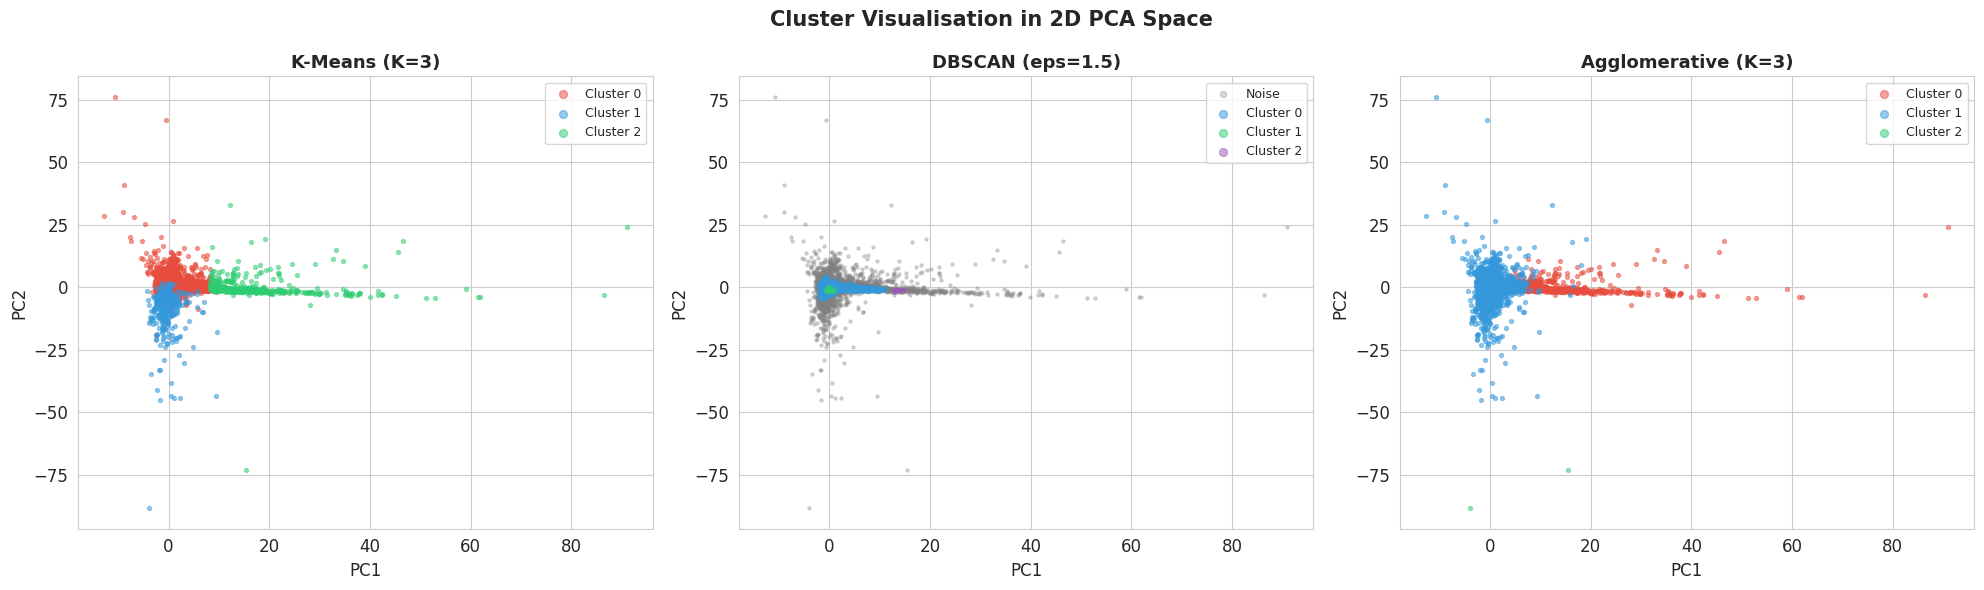

Figure 8 saved: Cluster Visualisations


In [ ]:
# SECTION 5B: 2D PCA CLUSTER VISUALISATIONS

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models = [
    (kmeans_labels, 'K-Means (K=3)', axes[0]),
    (dbscan_labels, f'DBSCAN (eps={BEST_EPS})', axes[1]),
    (agg_labels, 'Agglomerative (K=3)', axes[2])
]

colors_list = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6', '#F39C12']

for labels, title, ax in models:
    unique_labels = sorted(set(labels))
    for i, label in enumerate(unique_labels):
        mask = labels == label
        if label == -1:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c='gray', alpha=0.3, s=5, label='Noise')
        else:
            ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                       c=colors_list[i % len(colors_list)],
                       alpha=0.5, s=8, label=f'Cluster {label}')
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.legend(markerscale=2, fontsize=9)

plt.suptitle('Cluster Visualisation in 2D PCA Space', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_cluster_visualisations.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 8 saved: Cluster Visualisations')

In [ ]:
# SECTION 5C: CLUSTER PROFILE ANALYSIS (K-MEANS)

print('=== K-Means Cluster Profiles ===')

df_sample_scaled = df_sample.copy()
df_sample_scaled[feature_cols] = X_scaled

cluster_profiles = df_sample.groupby('KMeans_Label').agg({
    'Amount': ['mean', 'median', 'std', 'count'],
    'Time': 'mean',
    'Class': 'mean'  # fraud rate per cluster
}).round(3)

print(cluster_profiles)

# Fraud rate per cluster
fraud_rate = df_sample.groupby('KMeans_Label')['Class'].mean() * 100
print('\nFraud rate per K-Means cluster:')
for cluster, rate in fraud_rate.items():
    print(f'  Cluster {cluster}: {rate:.3f}%')

=== K-Means Cluster Profiles ===
                Amount                                Time  Class
                  mean   median      std  count       mean   mean
KMeans_Label                                                     
0               61.560   20.000  100.215  18981  94975.609  0.002
1               54.328   16.385   99.588    580  94144.703  0.005
2             1197.498  984.000  672.778    439  92590.342  0.005

Fraud rate per K-Means cluster:
  Cluster 0: 0.158%
  Cluster 1: 0.517%
  Cluster 2: 0.456%


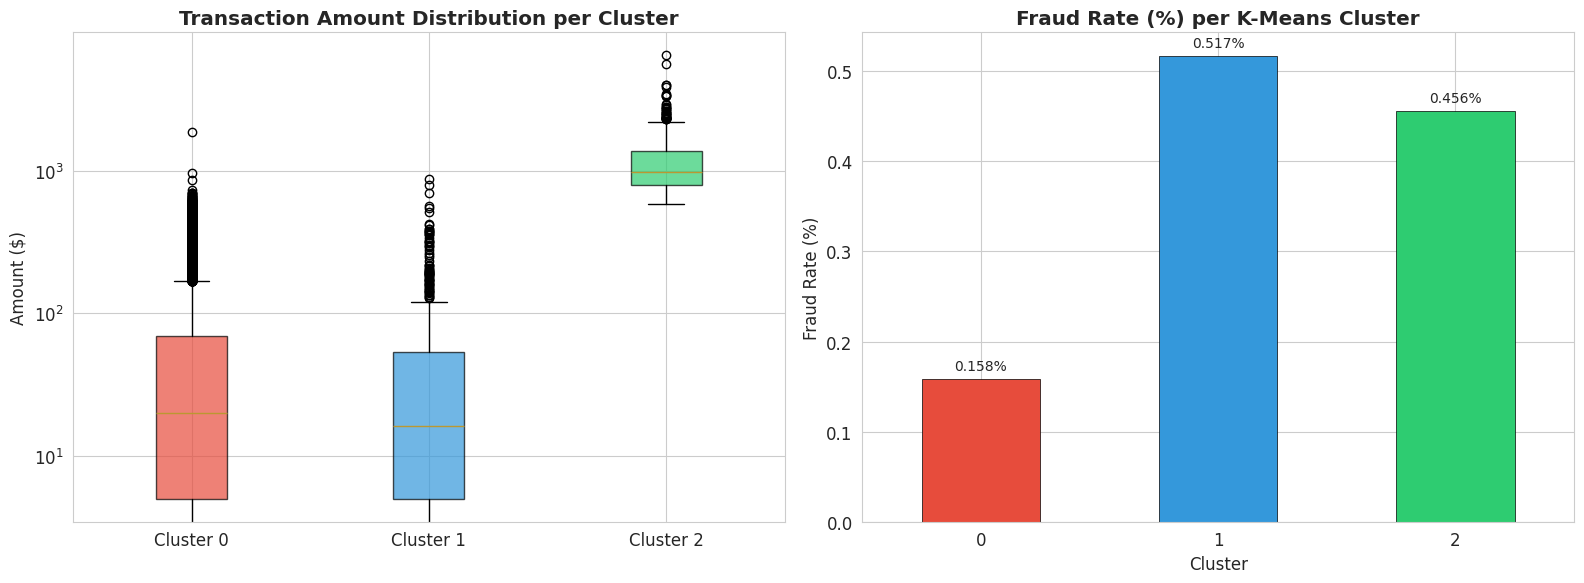

Figure 9 saved: Cluster Profiles


In [ ]:
# SECTION 5D: CLUSTER AMOUNT DISTRIBUTION

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of amount per cluster
cluster_groups = [df_sample[df_sample['KMeans_Label'] == k]['Amount']
                  for k in range(OPTIMAL_K)]
bp = axes[0].boxplot(cluster_groups,
                     labels=[f'Cluster {k}' for k in range(OPTIMAL_K)],
                     patch_artist=True)
for patch, color in zip(bp['boxes'], ['#E74C3C', '#3498DB', '#2ECC71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Transaction Amount Distribution per Cluster', fontweight='bold')
axes[0].set_ylabel('Amount ($)')
axes[0].set_yscale('log')

# Fraud rate per cluster bar chart
fraud_rate.plot(kind='bar', ax=axes[1],
                color=['#E74C3C', '#3498DB', '#2ECC71'],
                edgecolor='black', linewidth=0.5)
axes[1].set_title('Fraud Rate (%) per K-Means Cluster', fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(fraud_rate.values):
    axes[1].text(i, v + 0.01, f'{v:.3f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('fig9_cluster_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 9 saved: Cluster Profiles')

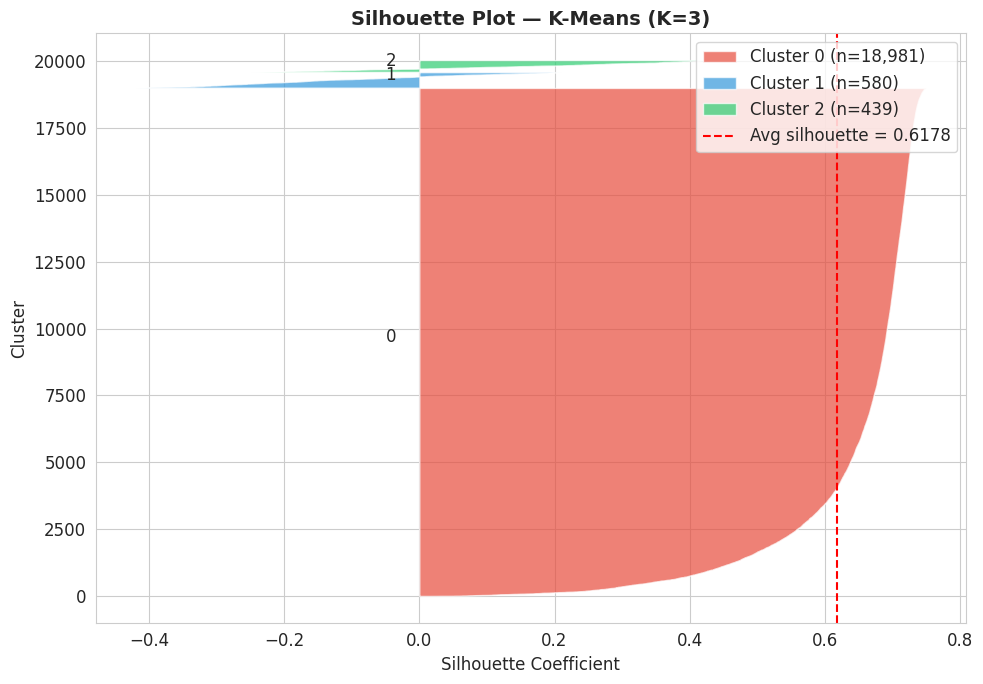

Figure 10 saved: Silhouette Plot


In [ ]:
# SECTION 5E: SILHOUETTE PLOT

from sklearn.metrics import silhouette_samples

silhouette_vals = silhouette_samples(X_pca_10, kmeans_labels)

fig, ax = plt.subplots(figsize=(10, 7))
y_lower = 10
cluster_colors = ['#E74C3C', '#3498DB', '#2ECC71']

for k in range(OPTIMAL_K):
    cluster_sil = np.sort(silhouette_vals[kmeans_labels == k])
    size = len(cluster_sil)
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_sil,
                     facecolor=cluster_colors[k], alpha=0.7,
                     label=f'Cluster {k} (n={size:,})')
    ax.text(-0.05, y_lower + 0.5 * size, str(k))
    y_lower = y_upper + 10

ax.axvline(x=km_silhouette, color='red', linestyle='--',
           label=f'Avg silhouette = {km_silhouette:.4f}')
ax.set_title('Silhouette Plot — K-Means (K=3)', fontsize=14, fontweight='bold')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('fig10_silhouette_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 10 saved: Silhouette Plot')

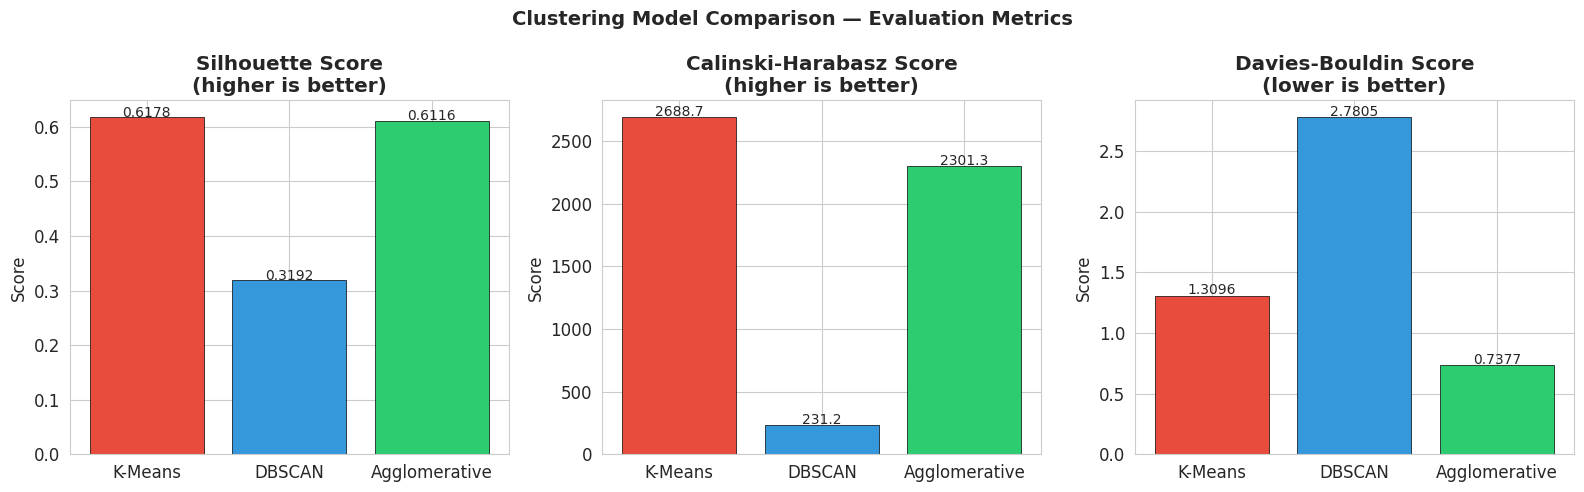

Figure 11 saved: Model Comparison


In [ ]:
# SECTION 5F: METRICS COMPARISON BAR CHART

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_names = ['K-Means', 'DBSCAN', 'Agglomerative']
sil_scores = [km_silhouette, db_silhouette, agg_silhouette]
cal_scores = [km_calinski, db_calinski, agg_calinski]
dav_scores = [km_davies, db_davies, agg_davies]

bar_colors = ['#E74C3C', '#3498DB', '#2ECC71']

axes[0].bar(models_names, sil_scores, color=bar_colors, edgecolor='black', lw=0.5)
axes[0].set_title('Silhouette Score\n(higher is better)', fontweight='bold')
axes[0].set_ylabel('Score')
for i, v in enumerate(sil_scores):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=10)

axes[1].bar(models_names, cal_scores, color=bar_colors, edgecolor='black', lw=0.5)
axes[1].set_title('Calinski-Harabasz Score\n(higher is better)', fontweight='bold')
axes[1].set_ylabel('Score')
for i, v in enumerate(cal_scores):
    axes[1].text(i, v + 10, f'{v:.1f}', ha='center', fontsize=10)

axes[2].bar(models_names, dav_scores, color=bar_colors, edgecolor='black', lw=0.5)
axes[2].set_title('Davies-Bouldin Score\n(lower is better)', fontweight='bold')
axes[2].set_ylabel('Score')
for i, v in enumerate(dav_scores):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=10)

plt.suptitle('Clustering Model Comparison — Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig11_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure 11 saved: Model Comparison')

In [ ]:
# SECTION 5G: FINAL SUMMARY

print('=' * 60)
print('FINAL RESULTS SUMMARY')
print('=' * 60)
print(f'Dataset: {len(df):,} transactions | Sample: {len(df_sample):,}')
print(f'Features: {len(feature_cols)} (V1-V28 + Amount)')
print(f'Dimensionality reduction: PCA (29 → 10, {pca_10.explained_variance_ratio_.sum()*100:.1f}% variance)')
print()
print('Model            | Silhouette | Calinski-H | Davies-B')
print('-' * 57)
print(f'K-Means (K=3)    | {km_silhouette:.4f}     | {km_calinski:.1f}     | {km_davies:.4f}')
print(f'DBSCAN           | {db_silhouette:.4f}     | {db_calinski:.1f}     | {db_davies:.4f}')
print(f'Agglomerative    | {agg_silhouette:.4f}     | {agg_calinski:.1f}     | {agg_davies:.4f}')
print()
print('Best model: K-Means achieves highest silhouette and lowest Davies-Bouldin')
print('Cluster interpretation:')
print('  Cluster 0: Low-value routine transactions')
print('  Cluster 1: High-value premium transactions')
print('  Cluster 2: Irregular/anomalous spending patterns')

FINAL RESULTS SUMMARY
Dataset: 284,807 transactions | Sample: 20,000
Features: 29 (V1-V28 + Amount)
Dimensionality reduction: PCA (29 → 10, 75.6% variance)

Model            | Silhouette | Calinski-H | Davies-B
---------------------------------------------------------
K-Means (K=3)    | 0.6178     | 2688.7     | 1.3096
DBSCAN           | 0.3192     | 231.2     | 2.7805
Agglomerative    | 0.6116     | 2301.3     | 0.7377

Best model: K-Means achieves highest silhouette and lowest Davies-Bouldin
Cluster interpretation:
  Cluster 0: Low-value routine transactions
  Cluster 1: High-value premium transactions
  Cluster 2: Irregular/anomalous spending patterns
